In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import geopandas as gpd
from shapely.geometry import Point

In [ ]:
conn = sqlite3.connect("base_tratada.db")

query = """
SELECT *
FROM base_tratada;
"""

df = pd.read_sql(query, conn)

# Visualizar os dados
df.head()

#testando se o banco conectou



,preco,hospedes,quartos,camas,nota_avaliacao,noites_minimas,quantidade_avaliacoes,tipo_de_propriedade,latitude,longitude,...,banheiros,tipo_quarto_Entire home/apt,tipo_quarto_Hotel room,tipo_quarto_Private room,tipo_quarto_Shared room,tipo_de_propriedade_grupo,bairro_encode,ano_mes,ipca_mensal,ipca_acumulado_ano
0,580.0,4,2.0,3.0,4.93,2,86,entire condo,-22.982818,-43.222457,...,1.5,1,0,0,0,1,76,2025-09-01 00:00:00,0.0048,0.0426
1,1900.0,2,1.0,1.0,NaN,5,0,entire rental unit,-22.984090,-43.191770,...,2.0,1,0,0,0,1,34,2025-09-01 00:00:00,0.0048,0.0426
2,700.0,4,1.0,1.0,NaN,1,0,entire rental unit,-22.814911,-43.379011,...,1.0,1,0,0,0,1,96,2025-09-01 00:00:00,0.0048,0.0426
3,NaN,2,NaN,NaN,5.00,2,3,private room in rental unit,-22.981910,-43.225990,...,1.0,0,0,1,0,4,76,2025-09-01 00:00:00,0.0048,0.0426
4,500.0,4,1.0,1.0,4.91,2,11,entire rental unit,-23.010000,-43.344820,...,1.0,1,0,0,0,1,8,2025-09-01 00:00:00,0.0048,0.0426


In [4]:

df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   preco                        38670 non-null  float64
 1   hospedes                     43068 non-null  int64  
 2   quartos                      42096 non-null  float64
 3   camas                        38660 non-null  float64
 4   nota_avaliacao               33882 non-null  float64
 5   noites_minimas               43068 non-null  int64  
 6   quantidade_avaliacoes        43068 non-null  int64  
 7   tipo_de_propriedade          43068 non-null  str    
 8   latitude                     43068 non-null  float64
 9   longitude                    43068 non-null  float64
 10  bairro                       43068 non-null  str    
 11  ano                          43068 non-null  int64  
 12  mes                          43068 non-null  int64  
 13  banheiros                  

In [6]:
df["preco"].describe()

#antes do tratamento de outliers

count     38670.000000
mean        717.535325
std        4388.082802
min          30.000000
25%         202.000000
50%         317.000000
75%         565.000000
max      500000.000000
Name: preco, dtype: float64

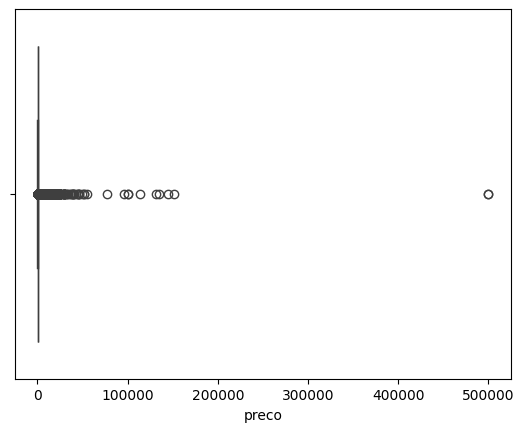

In [ ]:
sns.boxplot(x=df["preco"])
plt.show()

plt.show()

#grafico para avaliar os outliers no dataframe sem tratamento dos outliers


In [8]:
#outliers
df["preco"].sort_values(ascending=False).head(20)
#verificando valores

7624     500000.0
15026    500000.0
16440    151710.0
21203    144800.0
13282    134358.0
42536    131400.0
24598    114118.0
14389    100000.0
13880    100000.0
27939     96547.0
3146      76956.0
1854      55394.0
24256     51545.0
18525     51429.0
24053     50000.0
10694     45900.0
12548     45818.0
34736     45000.0
24697     45000.0
4401      42924.0
Name: preco, dtype: float64

In [9]:
df_tratado = df[df["preco"] <= 13000].copy()

#Limita o preco das diaria ate 13k

In [10]:
df.shape[0], df_tratado.shape[0]

#mostra os dois dataframes

(43068, 38506)

In [11]:

print(f"Antes: {df.shape[0]} linhas")
print(f"Depois: {df_tratado.shape[0]} linhas")
print(f"Removidos: {df.shape[0] - df_tratado.shape[0]} linhas")


Antes: 43068 linhas
Depois: 38506 linhas
Removidos: 4562 linhas


In [12]:
df_tratado["preco"].describe()

count    38506.000000
mean       579.125825
std        967.825157
min         30.000000
25%        201.000000
50%        315.000000
75%        558.000000
max      13000.000000
Name: preco, dtype: float64

In [13]:
df["preco"].sort_values(ascending=True).head(20)

#mostra valores em forma crescente

5386     30.0
6624     39.0
9388     40.0
42145    41.0
10249    42.0
24389    43.0
11471    43.0
42673    44.0
21734    44.0
14333    46.0
27704    46.0
4048     46.0
8908     46.0
6474     47.0
22890    48.0
9135     48.0
9908     48.0
37698    48.0
7530     48.0
8598     48.0
Name: preco, dtype: float64

In [14]:

df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= 65) &
    (df_tratado["quartos"] <= 15) &
    (df_tratado["banheiros"] <= 12)
].copy()

#atribui ao novo dataframe valores de limete pós remocao de outliers



In [15]:
print(f"Antes: {df_tratado.shape[0]} linhas")
print(f"Depois: {df_tratado_price_min.shape[0]} linhas")
print(f"Removidos: {df_tratado.shape[0] - df_tratado_price_min.shape[0]} linhas")

Antes: 38506 linhas
Depois: 37937 linhas
Removidos: 569 linhas


In [16]:
df_tratado_price_min["preco"].describe()

count    37937.000000
mean       583.569971
std        971.368256
min         65.000000
25%        204.000000
50%        319.000000
75%        563.000000
max      13000.000000
Name: preco, dtype: float64

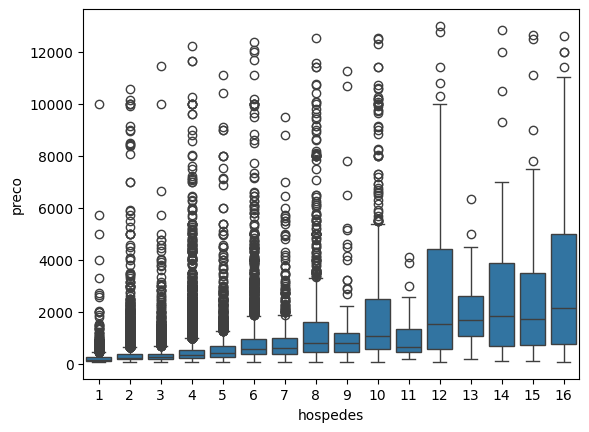

In [58]:
sns.boxplot(x="hospedes", y="preco", data=df_tratado_price_min)
plt.show()

In [99]:

Q1 = df_tratado["preco"].quantile(0.25)
Q3 = df_tratado["preco"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


In [100]:

df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= limite_inferior) &
    (df_tratado["preco"] <= limite_superior) &
    (df_tratado["quartos"] <= 15) &
    (df_tratado["banheiros"] <= 12)
].copy()


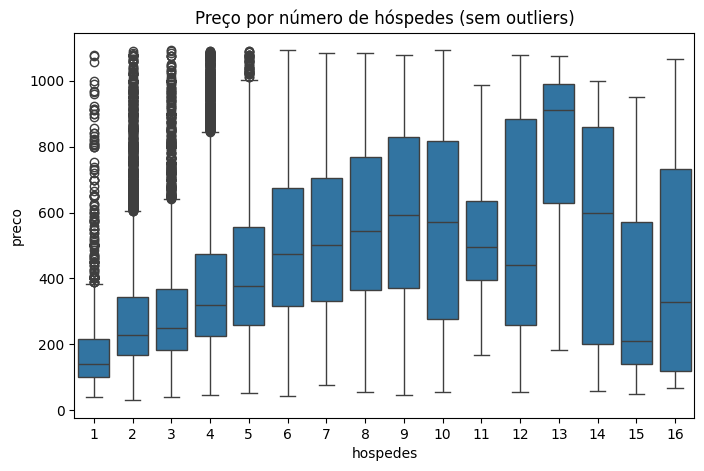

In [101]:

plt.figure(figsize=(8, 5))
sns.boxplot(x="hospedes", y="preco", data=df_tratado_price_min)
plt.title("Preço por número de hóspedes (sem outliers)")
plt.show()


In [102]:

print("Registros originais:", len(df_tratado))
print("Registros após remoção de outliers:", len(df_tratado_price_min))


Registros originais: 38506
Registros após remoção de outliers: 34425


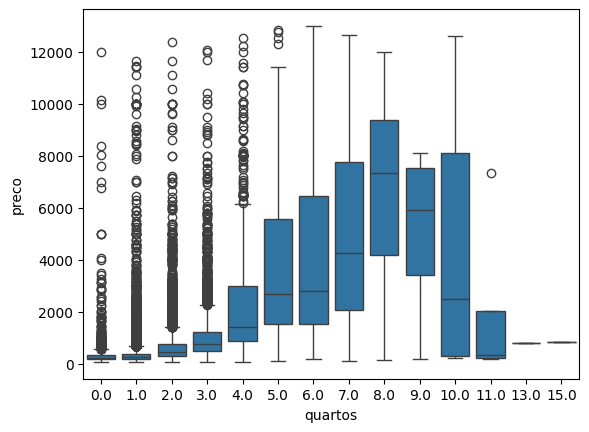

In [59]:
sns.boxplot(x="quartos", y="preco", data=df_tratado_price_min)
plt.show()

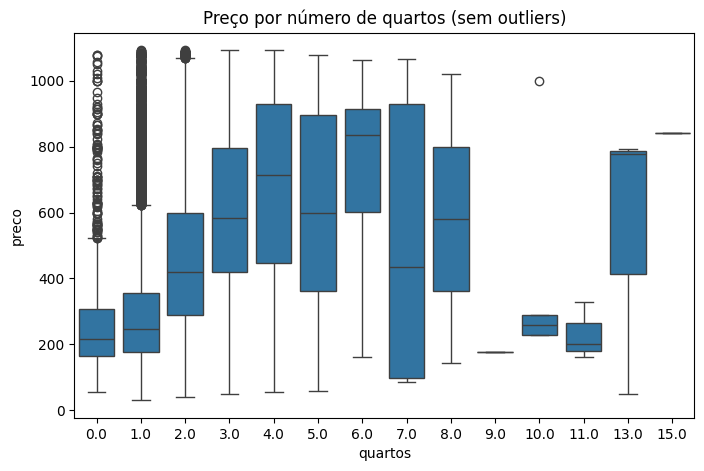

In [103]:

Q1 = df_tratado["preco"].quantile(0.25)
Q3 = df_tratado["preco"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= limite_inferior) &
    (df_tratado["preco"] <= limite_superior) &
    (df_tratado["quartos"] <= 15) &
    (df_tratado["banheiros"] <= 12)
].copy()


plt.figure(figsize=(8, 5))
sns.boxplot(x="quartos", y="preco", data=df_tratado_price_min)
plt.title("Preço por número de quartos (sem outliers)")
plt.show()



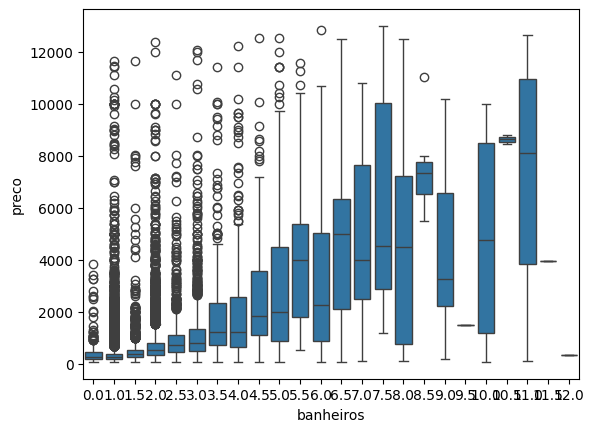

In [60]:
sns.boxplot(x="banheiros", y="preco", data=df_tratado_price_min)
plt.show()

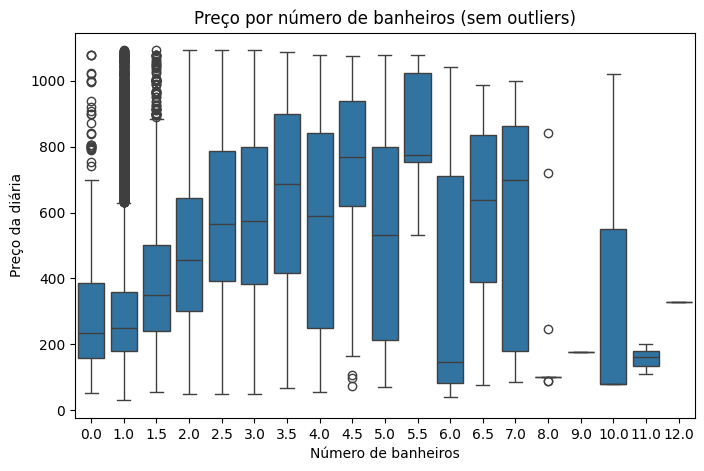

In [104]:

Q1 = df_tratado["preco"].quantile(0.25)
Q3 = df_tratado["preco"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= limite_inferior) &
    (df_tratado["preco"] <= limite_superior) &
    (df_tratado["banheiros"] <= 12)
].copy()


plt.figure(figsize=(8, 5))
sns.boxplot(x="banheiros", y="preco", data=df_tratado_price_min)
plt.title("Preço por número de banheiros (sem outliers)")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária")
plt.show()



In [20]:

df_tratado_price_min[
    [
        "preco",
        "hospedes",
        "quartos",
        "camas",
        "nota_avaliacao",
        "noites_minimas",
        "quantidade_avaliacoes",
        "latitude",
        "longitude",
        "banheiros",
        "tipo_quarto_Entire home/apt",
        "tipo_quarto_Hotel room",
        "tipo_quarto_Private room",
        "tipo_quarto_Shared room"
    ]
].describe()


,preco,hospedes,quartos,camas,nota_avaliacao,noites_minimas,quantidade_avaliacoes,latitude,longitude,banheiros,tipo_quarto_Entire home/apt,tipo_quarto_Hotel room,tipo_quarto_Private room,tipo_quarto_Shared room
count,37937.000000,37937.000000,37937.000000,37926.000000,30161.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000
mean,583.569971,3.983631,1.498353,2.366240,4.814117,3.430450,27.821098,-22.966040,-43.248507,1.479756,0.818779,0.000395,0.173182,0.007644
std,971.368256,2.284737,0.942994,2.070306,0.351818,13.370886,50.298927,0.035845,0.101305,0.922917,0.385207,0.019881,0.378409,0.087098
min,65.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-23.072920,-43.713593,0.000000,0.000000,0.000000,0.000000,0.000000
25%,204.000000,2.000000,1.000000,1.000000,4.770000,1.000000,1.000000,-22.984323,-43.301941,1.000000,1.000000,0.000000,0.000000,0.000000
50%,319.000000,4.000000,1.000000,2.000000,4.920000,2.000000,8.000000,-22.971860,-43.193427,1.000000,1.000000,0.000000,0.000000,0.000000
75%,563.000000,5.000000,2.000000,3.000000,5.000000,3.000000,32.000000,-22.952940,-43.184380,2.000000,1.000000,0.000000,0.000000,0.000000
max,13000.000000,16.000000,15.000000,50.000000,5.000000,730.000000,760.000000,-22.750510,-43.104400,12.000000,1.000000,1.000000,1.000000,1.000000


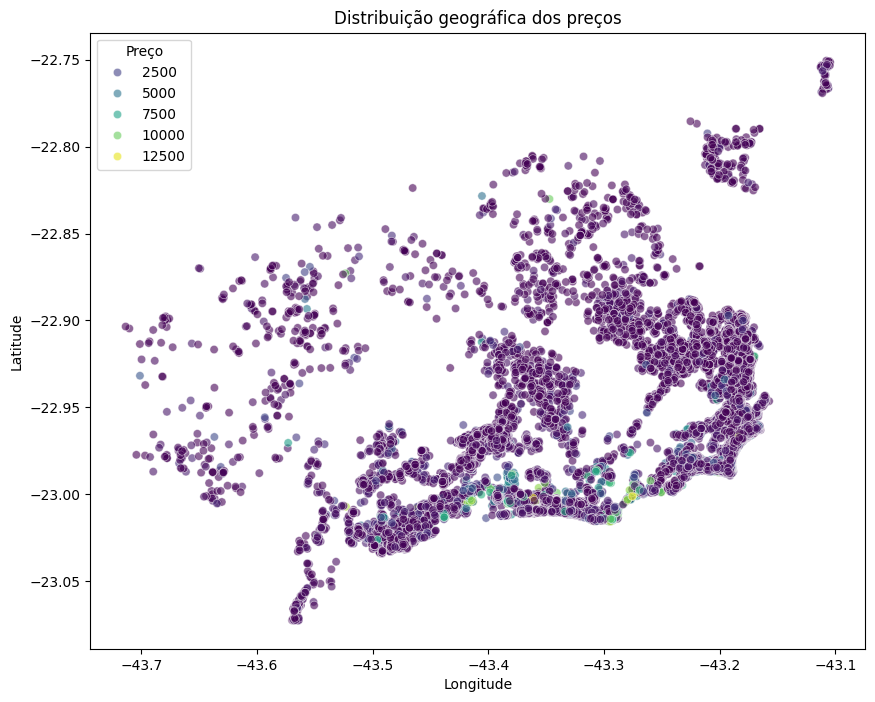

In [21]:

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_tratado_price_min,
    x="longitude",
    y="latitude",
    hue="preco",
    palette="viridis",
    alpha=0.6
)

plt.title("Distribuição geográfica dos preços")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Preço", loc="best")
plt.show()


In [22]:

df_tratado_price_min["lat_bin"] = df_tratado_price_min["latitude"].round(2)
df_tratado_price_min["lon_bin"] = df_tratado_price_min["longitude"].round(2)


In [23]:

media_localizacao = (
    df_tratado_price_min
    .groupby(["lat_bin", "lon_bin"])["preco"]
    .mean()
    .reset_index()
)


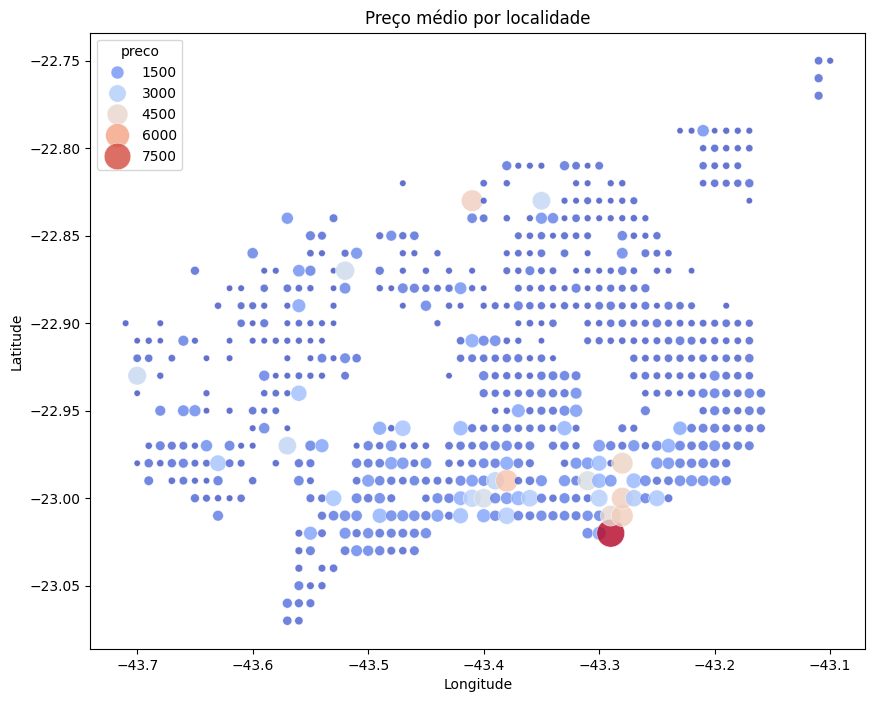

In [24]:

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=media_localizacao,
    x="lon_bin",
    y="lat_bin",
    size="preco",
    hue="preco",
    palette="coolwarm",
    sizes=(20, 400),
    alpha=0.8
)

plt.title("Preço médio por localidade")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [95]:

tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room",
    "Outros": "tipo_de_propriedade_grupo"
}



In [98]:

frequencias = []
total_registros = len(df_tratado_price_min)

for nome, coluna in tipos_imovel.items():
    freq_absoluta = df_tratado_price_min[coluna].sum()
    freq_relativa = freq_absoluta / total_registros

    frequencias.append({
        "Tipo de imóvel": nome,
        "Frequência relativa": freq_relativa
    })

df_frequencia = pd.DataFrame(frequencias)
df_frequencia["Frequência (%)"] = df_frequencia["Frequência relativa"] * 100

# =========================
# TABELA FINAL
# =========================

df_frequencia



,Tipo de imóvel,Frequência relativa,Frequência (%)
0,Casa/apt Inteiro,0.818779,81.877850
1,Quarto de Hotel,0.000395,0.039539
2,Quarto Privado,0.173182,17.318185
3,Quarto Compartilhado,0.007644,0.764425
4,Outros,1.507367,150.736748


In [ ]:
tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room",
    "Outros": "tipo_de_propriedade_grupo"
}


In [ ]:
media_precos = []

for nome, coluna in tipos_imovel.items():
    preco_medio = df_tratado_price_min.loc[
        df_tratado_price_min[coluna] == 1, "preco"
    ].mean()
    
    media_precos.append({
        "Tipo de imóvel": nome,
        "Preço médio": preco_medio
    })

df_media = pd.DataFrame(media_precos)
df_media


,Tipo de imóvel,Preço médio
0,Casa/apt Inteiro,642.679544
1,Quarto de Hotel,619.800000
2,Quarto Privado,322.841705
3,Quarto Compartilhado,157.293103
4,Outros,641.653193


C:\Users\UL236KK\AppData\Local\Temp\ipykernel_29148\887207099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


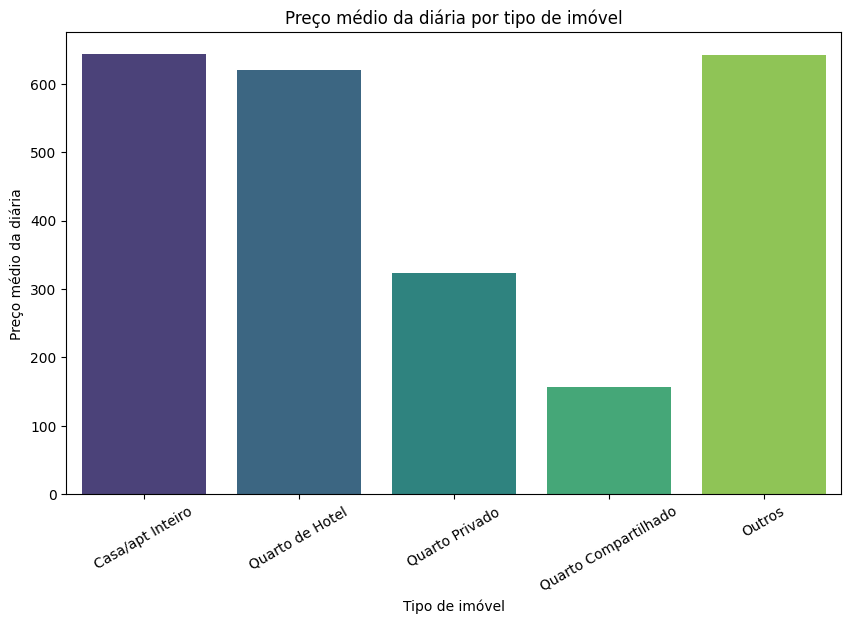

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_media,
    x="Tipo de imóvel",
    y="Preço médio",
    palette="viridis"
)

plt.title("Preço médio da diária por tipo de imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Preço médio da diária")
plt.xticks(rotation=30)
plt.show()


C:\Users\UL236KK\AppData\Local\Temp\ipykernel_29148\4172273771.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


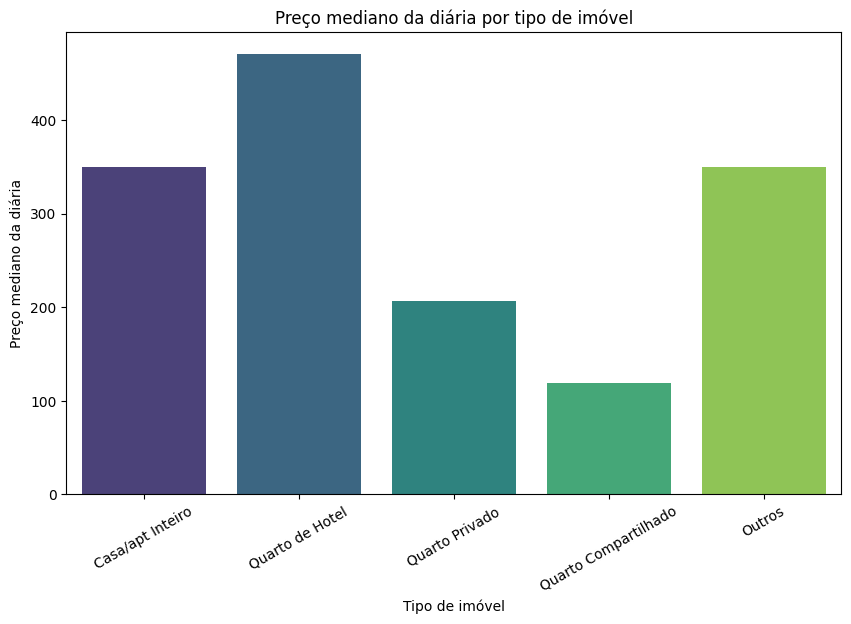

In [69]:
tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room",
    "Outros": "tipo_de_propriedade_grupo"
}



mediana_precos = []

for nome, coluna in tipos_imovel.items():
    preco_mediano = df_tratado_price_min.loc[
        df_tratado_price_min[coluna] == 1, "preco"
    ].median()
    
    mediana_precos.append({
        "Tipo de imóvel": nome,
        "Preço mediano": preco_mediano
    })

df_mediana = pd.DataFrame(mediana_precos)

df_mediana


plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mediana,
    x="Tipo de imóvel",
    y="Preço mediano",
    palette="viridis"
)

plt.title("Preço mediano da diária por tipo de imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Preço mediano da diária")
plt.xticks(rotation=30)
plt.show()




C:\Users\UL236KK\AppData\Local\Temp\ipykernel_29148\162831258.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


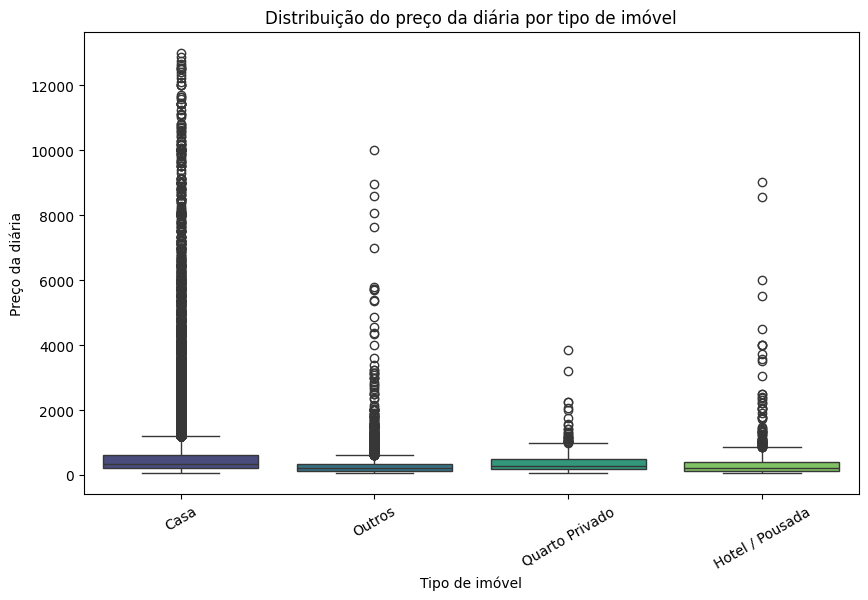

In [70]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="tipo_imovel_label",
    y="preco",
    palette="viridis"
)

plt.title("Distribuição do preço da diária por tipo de imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Preço da diária")
plt.xticks(rotation=30)
plt.show()


In [35]:
df_tratado_price_min[df_tratado_price_min["bairro"] == "Copacabana"]["preco"].mean()

np.float64(501.7656826568266)

In [36]:

top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)


In [37]:

df_media_acomodacao = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .mean()
    .reset_index()
)

# manter apenas bairros mais procurados
df_media_acomodacao = df_media_acomodacao.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


In [38]:

df_media_acomodacao = df_media_acomodacao.sort_values("preco", ascending=False)


C:\Users\UL236KK\AppData\Local\Temp\ipykernel_29148\2460075909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


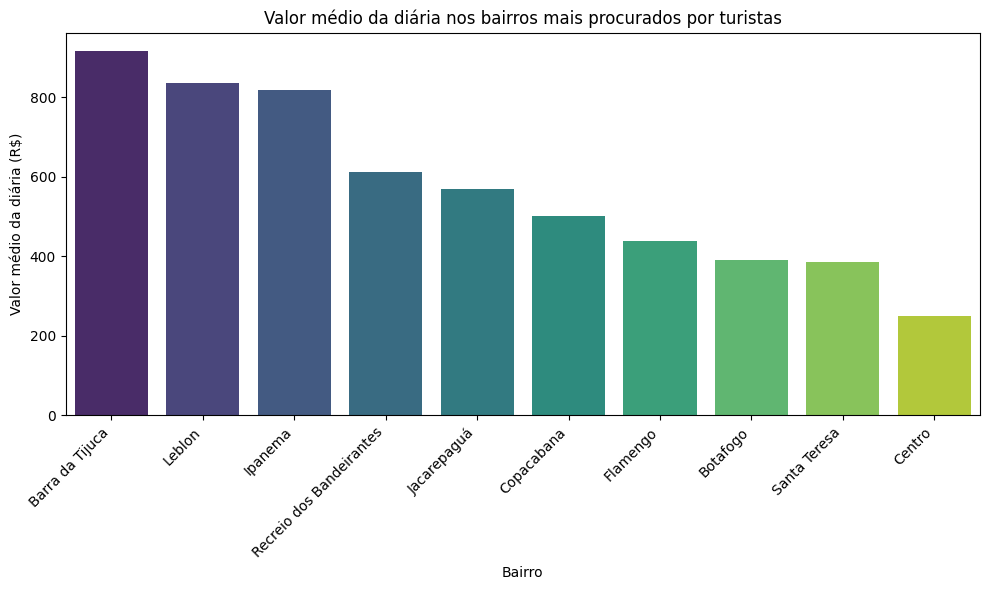

In [39]:

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_media_acomodacao,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Valor médio da diária nos bairros mais procurados por turistas")
plt.xlabel("Bairro")
plt.ylabel("Valor médio da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


C:\Users\UL236KK\AppData\Local\Temp\ipykernel_29148\4196697961.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


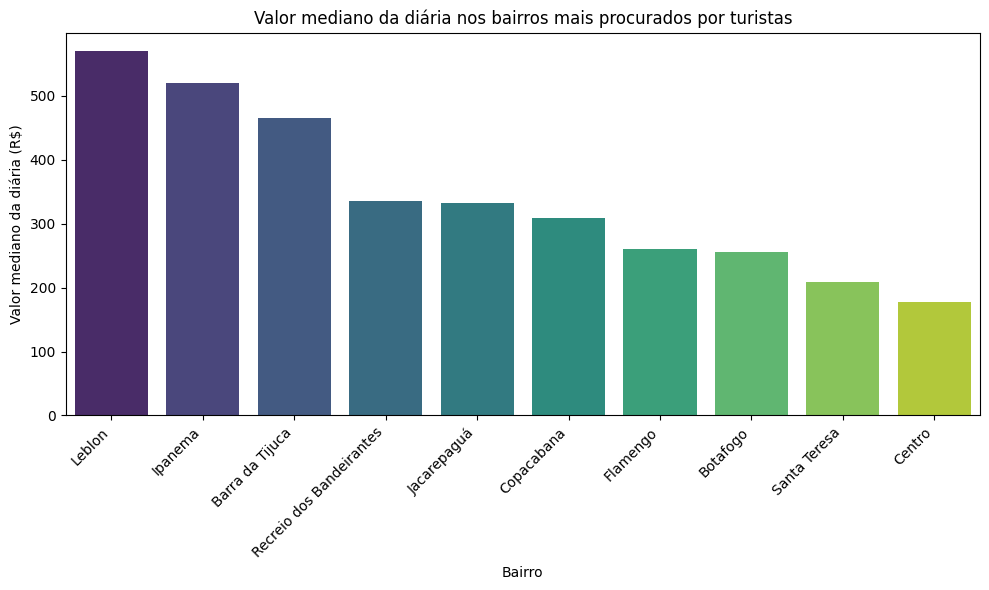

In [71]:

top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)


df_mediana_acomodacao = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .median()
    .reset_index()
)


df_mediana_acomodacao = df_mediana_acomodacao.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


df_mediana_acomodacao = df_mediana_acomodacao.sort_values(
    "preco",
    ascending=False
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mediana_acomodacao,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Valor mediano da diária nos bairros mais procurados por turistas")
plt.xlabel("Bairro")
plt.ylabel("Valor mediano da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()




C:\Users\UL236KK\AppData\Local\Temp\ipykernel_29148\3330698642.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


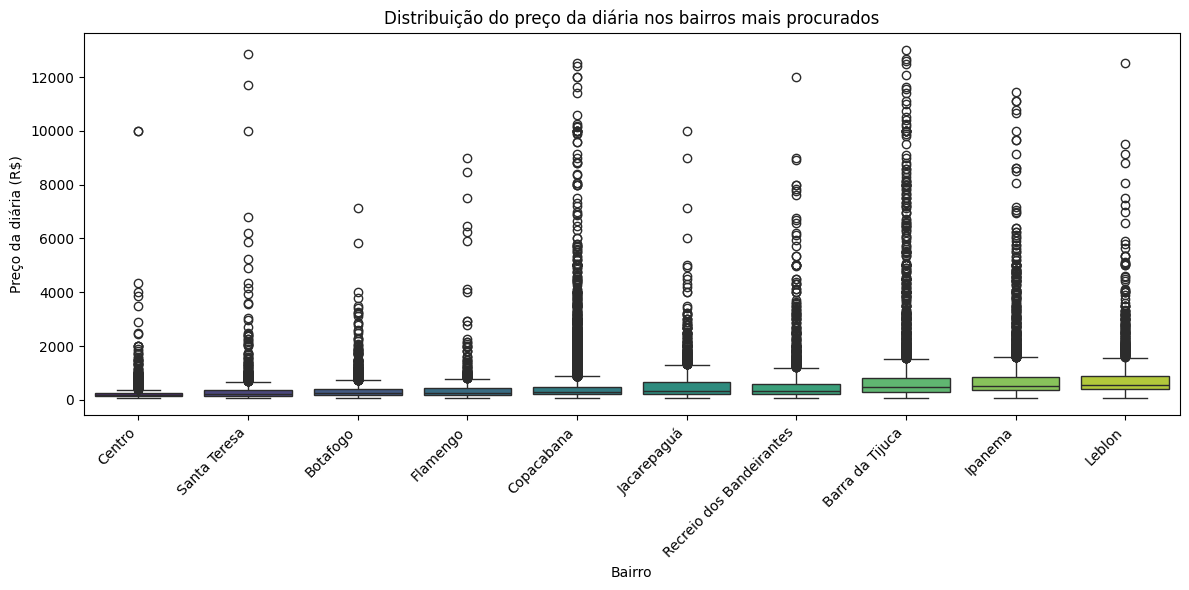

In [72]:

df_top_bairros = df_tratado_price_min.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


ordem_bairros = (
    df_top_bairros
    .groupby("bairro")["preco"]
    .median()
    .sort_values()
    .index
)


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_bairros,
    x="bairro",
    y="preco",
    order=ordem_bairros,
    palette="viridis"
)

plt.title("Distribuição do preço da diária nos bairros mais procurados")
plt.xlabel("Bairro")
plt.ylabel("Preço da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



In [44]:

variaveis = [
    "preco",
    "quartos",
    "banheiros",
    "latitude",
    "longitude",
    "camas",
    "nota_avaliacao",
    "quantidade_avaliacoes",
    "tipo_quarto_Entire home/apt",
    "tipo_quarto_Hotel room",
    "tipo_quarto_Private room",
    "tipo_quarto_Shared room"
]

df_corr = df_tratado_price_min[variaveis]


In [45]:
corr_matrix = df_corr.corr()

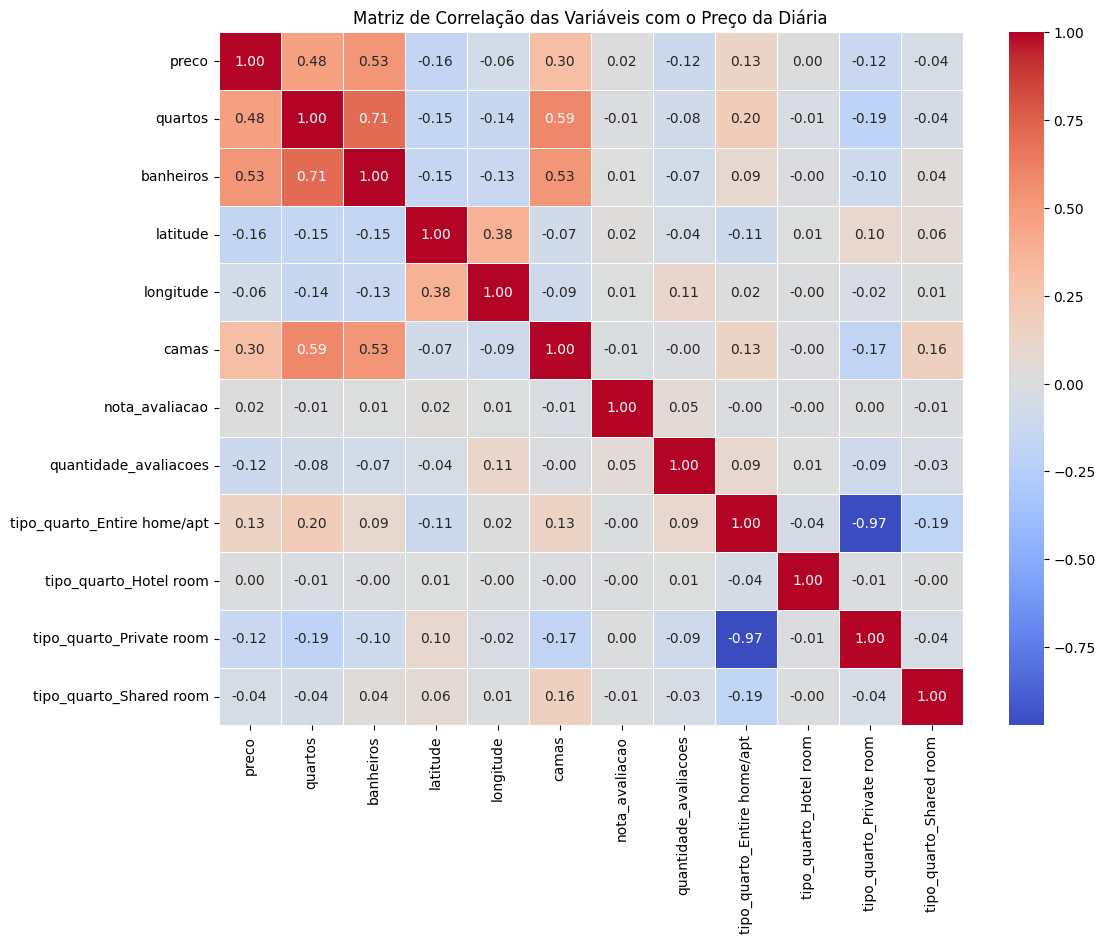

In [46]:

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis com o Preço da Diária")
plt.show()


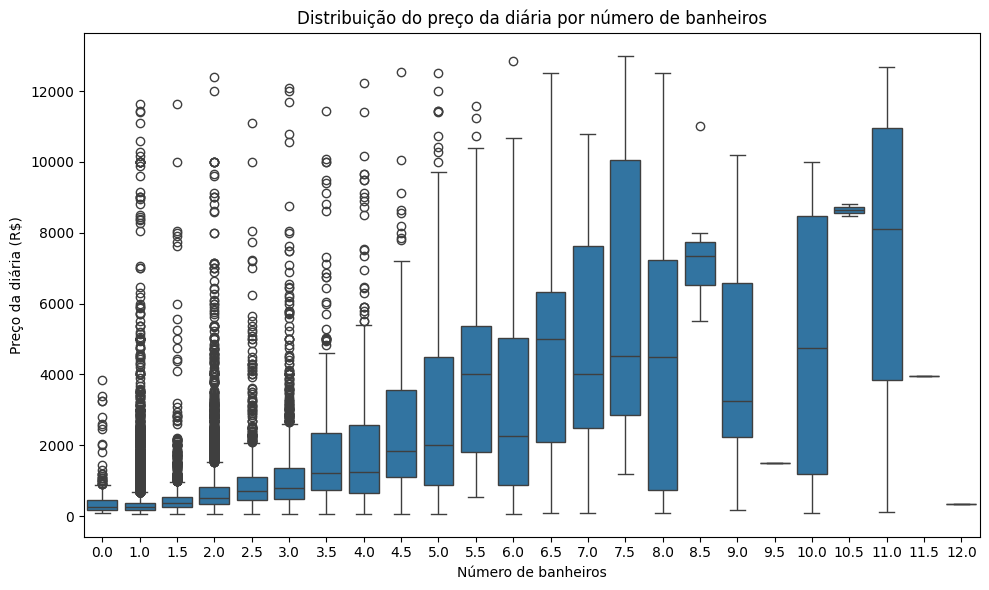

In [57]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="banheiros",
    y="preco"
)

plt.title("Distribuição do preço da diária por número de banheiros")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária (R$)")
plt.tight_layout()
plt.show()
